In [1]:
# ch04_LANGGRAPH_ARCHITECTURE.ipynb

In [2]:
# 출력 구조화 

from pydantic import BaseModel, Field
from langchain.chat_models import init_chat_model

# 1) 스키마 정의
class SearchQuery(BaseModel):
    search_query: str = Field(..., description="웹 검색에 최적화된 질의문")
    justification: str = Field(..., description="해당 질의가 왜 적절한지의 근거")

# 2) 구조화된 출력으로 LLM 래핑
llm = init_chat_model("openai:gpt-4.1")
structured_llm = llm.with_structured_output(SearchQuery)

# 3) 프롬프트 실행
prompt = "랭그래프가 왜 필요한가?"
result = structured_llm.invoke(prompt)

# 4) 사용
print("검색어:", result.search_query)
print("근거:", result.justification)

검색어: 랭그래프(랭귀지 그래프)가 필요한 이유와 활용 사례
근거: 사용자가 '랭그래프'의 필요성에 대해 묻고 있습니다. 이를 위해서는 랭그래프의 정의, 왜 쓰이는지, 어떤 문제를 해결하는지, 활용 분야 등이 포함된 설명이 필요하므로 관련 정보와 사례를 검색해야 적합한 답변을 제공할 수 있습니다.


In [3]:
# 도구 호출

# 1) 도구 정의
def multiply(a: int, b: int) -> int:
    """두 수의 곱을 반환"""
    return a * b

# 2) LLM에 도구 바인딩
agent = llm.bind_tools([multiply])

# 3) 사용자 질문
user_msg = "2 곱하기 3은?"

# 4) 1차 LLM 호출 -> 도구 호출 의도 파악
msg = agent.invoke(user_msg)

# 5) tool_calls 확인 및 실행
results = {}
print(msg.tool_calls)

for call in getattr(msg, "tool_calls", []):
    name = call["name"]
    args = call["args"]
    if name == "multiply":
        results[name] = multiply(**args)
print(results)

[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': 'call_2CSW8NhJI8lnvTRbMOEfZNwy', 'type': 'tool_call'}]
{'multiply': 6}


In [4]:
# 프롬프트 체이닝 

from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

class State(TypedDict):
    topic: str
    joke: str
    improved_joke: str
    final_joke: str


In [5]:
# 1) 농담 생성
def generate_joke(state: State):
    msg = llm.invoke(f"{state['topic']}에 대한 짧은 농담을 작성해 주세요.")
    return {"joke": msg.content}

# 2) 품질 검사(펀치라인 확인)
def check_punchline(state: State):
    if "?" in state["joke"] or "!" in state["joke"]:
        return "Pass"
    return "Fail"

# 3) 농담 개선
def improve_joke(state: State):
    msg = llm.invoke(f"다음 농담에 말장난을 넣어 더 재미있게 만들어 주세요: {state['joke']}")
    return {"improved_joke": msg.content}

# 4) 농담 다듬기
def polish_joke(state: State):
    msg = llm.invoke(f"다음 농담에 예상치 못한 반전을 추가해 주세요: {state['improved_joke']}")
    return {"final_joke": msg.content}


In [6]:
workflow = StateGraph(State)

# 노드 등록
workflow.add_node("generate_joke", generate_joke)
workflow.add_node("improve_joke", improve_joke)
workflow.add_node("polish_joke", polish_joke)

# 순서 연결
workflow.add_edge(START, "generate_joke")
workflow.add_conditional_edges(
    "generate_joke", check_punchline, {"Fail": "improve_joke", "Pass": END}
)
workflow.add_edge("improve_joke", "polish_joke")
workflow.add_edge("polish_joke", END)

# 워크플로 컴파일
chain = workflow.compile()


In [7]:
state = chain.invoke({"topic": "한국"})

print("Initial joke:")
print(state["joke"])
print("\n--- --- ---\n")

if "improved_joke" in state:
    print("Improved joke:")
    print(state["improved_joke"])
    print("\n--- --- ---\n")

    print("Final joke:")
    print(state["final_joke"])
else:
    print("농담이 품질 검사를 통과하여 개선이 필요하지 않습니다!")


Initial joke:
한국에 대한 짧은 농담 하나 소개할게요!

왜 한국 사람들은 항상 시간이 빠르다고 생각할까요?  
왜냐면 "빨리빨리" 하니까요!

--- --- ---

농담이 품질 검사를 통과하여 개선이 필요하지 않습니다!


In [8]:
# 병렬 처리

# 상태 정의
class State(TypedDict):
    topic: str
    joke: str
    story: str
    poem: str
    combined_output: str


# 1) 농담 생성
def call_llm_1(state: State):
    msg = llm.invoke(f"{state['topic']}에 대한 농담을 작성해 주세요.")
    return {"joke": msg.content}

# 2) 이야기 생성
def call_llm_2(state: State):
    msg = llm.invoke(f"{state['topic']}에 대한 이야기를 짧게 작성해 주세요.")
    return {"story": msg.content}

# 3) 시 생성
def call_llm_3(state: State):
    msg = llm.invoke(f"{state['topic']}에 대한 시를 작성해 주세요.")
    return {"poem": msg.content}

# 4) 결과 합치기
def aggregator(state: State):
    combined = f"{state['topic']}에 관한 이야기, 농담, 시입니다!\n\n"
    combined += f"이야기:\n{state['story']}\n\n"
    combined += f"농담:\n{state['joke']}\n\n"
    combined += f"시:\n{state['poem']}"
    return {"combined_output": combined}


In [9]:
parallel_builder = StateGraph(State)

# 노드 등록
parallel_builder.add_node("call_llm_1", call_llm_1)
parallel_builder.add_node("call_llm_2", call_llm_2)
parallel_builder.add_node("call_llm_3", call_llm_3)
parallel_builder.add_node("aggregator", aggregator)

# 병렬 연결
parallel_builder.add_edge(START, "call_llm_1")
parallel_builder.add_edge(START, "call_llm_2")
parallel_builder.add_edge(START, "call_llm_3")

# 결과 합치기
parallel_builder.add_edge("call_llm_1", "aggregator")
parallel_builder.add_edge("call_llm_2", "aggregator")
parallel_builder.add_edge("call_llm_3", "aggregator")
parallel_builder.add_edge("aggregator", END)

# 컴파일
parallel_workflow = parallel_builder.compile()


In [10]:
state = parallel_workflow.invoke({"topic": "한국"})
print(state["combined_output"])

한국에 관한 이야기, 농담, 시입니다!

이야기:
한국은 동아시아에 위치한 나라로, 공식 명칭은 대한민국입니다. 서울이 수도이며, 한글이라는 독창적인 문자를 사용합니다. 한국은 오랜 역사와 풍부한 문화유산을 지니고 있으며, 현대에는 K-팝과 드라마, IT 산업 등으로 세계적으로 큰 영향력을 발휘하고 있습니다.

농담:
물론이죠! 가볍고 재미있는 한국 관련 농담 하나 준비해 봤어요:

한류 드라마가 왜 항상 긴장감 넘칠까요?  
왜냐하면 "김치" 볼 때마다 "깍두기" 때문이죠!

(김치=긴치, 깍두기=깍두기(긴장 풀릴 타이밍에 방해하는 느낌))

원하신다면 더 다양한 농담이나, 다른 스타일의 유머도 준비해 드릴 수 있습니다!

시:
푸른 산이 어깨를 맞대고  
강물은 조용히 다리 아래 흐른다  
네 계절, 바람 따라 물드는 들판  
매화 피고 지는 골목길마다  
어머니의 손길 같은 따스함이 스민다  

고요한 새벽, 종소리 울리면  
사람들은 바쁜 걸음으로 하루를 시작한다  
김치의 붉은빛, 찬란한 저녁노을처럼  
작은 행복이 모여 큰 꿈을 키우고  
슬픔을 견뎌 온 시간 위에  
희망은 다시 푸르게 싹튼다  

바다를 품은 이 땅  
수많은 이야기가 이어진다  
지금도 낯선 미래를 향해  
한 걸음, 한 걸음  
함께 걸어가는  
그 이름,  
한국


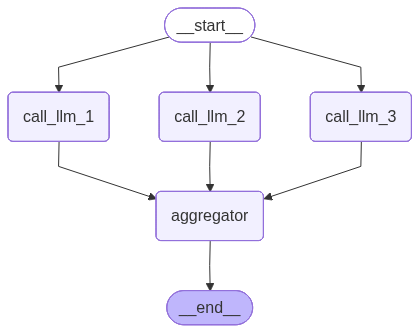

In [11]:
from IPython.display import Image, display

# 다이어그램 출력
display(Image(parallel_workflow.get_graph().draw_mermaid_png()))


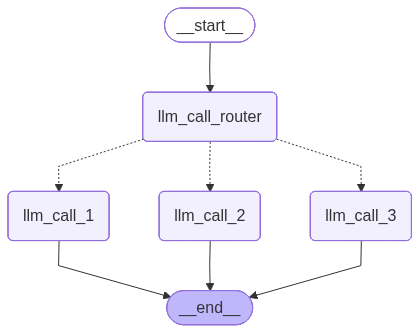

왜 김치는 항상 파티에 초대받을까요?  
왜냐하면 김~치~는 분위기를 띄우니까요!


In [12]:
# 라우팅

from typing_extensions import Literal
from langchain_core.messages import HumanMessage, SystemMessage

# 1) 라우팅 결정을 위한 구조화 출력 스키마
class Route(BaseModel):
    step: Literal["poem", "story", "joke"] = Field(
        None, description="라우팅의 다음 단계"
    )

# 2) 구조화 출력으로 동작하는 라우터 LLM
router = llm.with_structured_output(Route)

# 3) 상태 정의
class State(TypedDict):
    input: str
    decision: str
    output: str

# 4) 노드 정의 (각각 전용 프롬프트 사용)
def llm_call_1(state: State):
    """이야기 작성"""
    result = llm.invoke(f"다음 주제로 짧은 이야기를 작성해 주세요: {state['input']}")
    return {"output": result.content}

def llm_call_2(state: State):
    """농담 작성"""
    result = llm.invoke(f"다음 주제로 짧은 농담을 작성해 주세요: {state['input']}")
    return {"output": result.content}

def llm_call_3(state: State):
    """시 작성"""
    result = llm.invoke(f"다음 주제로 짧은 시를 작성해 주세요: {state['input']}")
    return {"output": result.content}

def llm_call_router(state: State):
    """입력을 적절한 노드로 라우팅"""
    decision = router.invoke(
        [
            SystemMessage(
                content="사용자 요청을 이야기(story), 농담(joke), 시(poem) 중 하나로 분류하고, "
                        "가장 알맞은 항목을 step에 지정하세요."
            ),
            HumanMessage(content=state["input"]),
        ]
    )
    return {"decision": decision.step}

# 5) 조건부 엣지에서 분기 로직
def route_decision(state: State):
    if state["decision"] == "story":
        return "llm_call_1"
    elif state["decision"] == "joke":
        return "llm_call_2"
    elif state["decision"] == "poem":
        return "llm_call_3"

# 6) 워크플로 구성
router_builder = StateGraph(State)
router_builder.add_node("llm_call_1", llm_call_1)
router_builder.add_node("llm_call_2", llm_call_2)
router_builder.add_node("llm_call_3", llm_call_3)
router_builder.add_node("llm_call_router", llm_call_router)

router_builder.add_edge(START, "llm_call_router")
router_builder.add_conditional_edges(
    "llm_call_router",
    route_decision,
    {
        "llm_call_1": "llm_call_1",
        "llm_call_2": "llm_call_2",
        "llm_call_3": "llm_call_3",
    },
)
router_builder.add_edge("llm_call_1", END)
router_builder.add_edge("llm_call_2", END)
router_builder.add_edge("llm_call_3", END)

router_workflow = router_builder.compile()

# 7) 다이어그램 확인
display(Image(router_workflow.get_graph().draw_mermaid_png()))

# 8) 실행
state = router_workflow.invoke({"input": "한국에 대한 농담을 써 주세요"})
print(state["output"])


In [13]:
# 오케스트레이터-워커 

from typing import Annotated, List
from langgraph.types import Send
import operator

# 보고서 섹션(Section) 정의
class Section(BaseModel):
    name: str = Field(description="이 보고서 섹션의 제목")
    description: str = Field(description="이 섹션에서 다룰 주요 주제와 개념에 대한 간략한 설명")

# 보고서 섹션 목록 구조
class Sections(BaseModel):
    sections: List[Section] = Field(description="보고서의 각 섹션 목록")

# LLM에 구조화 출력(Structured Output) 스키마를 적용
planner = llm.with_structured_output(Sections)

# 전체 워크플로 상태
class State(TypedDict):
    topic: str  # 보고서 주제
    sections: list[Section]  # 보고서 섹션 목록
    completed_sections: Annotated[list, operator.add]  # 모든 워커가 작성한 섹션 결과 모음
    final_report: str  # 최종 보고서

# 워커 상태
class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]


In [14]:
def orchestrator(state: State):
    """보고서 목차를 생성하는 오케스트레이터"""

    report_sections = planner.invoke([
        SystemMessage(content="보고서 목차를 생성해 주세요."),
        HumanMessage(content=f"보고서 주제: {state['topic']}"),
    ])
    return {"sections": report_sections.sections}


In [15]:
def llm_call(state: WorkerState):
    """각 보고서 섹션을 작성하는 워커"""

    section = llm.invoke([
        SystemMessage(content="제공된 제목과 설명에 따라 보고서 섹션을 작성하세요. 각 섹션에 머리말은 포함하지 말고, 마크다운 형식을 사용하세요."),
        HumanMessage(content=f"섹션 제목: {state['section'].name}\n설명: {state['section'].description}"),
    ])

    return {"completed_sections": [section.content]}


In [16]:
def synthesizer(state: State):
    """작성된 섹션들을 종합하여 최종 보고서 생성"""

    completed_sections = state["completed_sections"]
    combined_report = "\n\n---\n\n".join(completed_sections)
    return {"final_report": combined_report}


In [17]:
def assign_workers(state: State):
    """각 섹션에 워커 할당"""
    return [Send("llm_call", {"section": s}) for s in state["sections"]]


In [18]:
# 워크플로 빌더 생성
builder = StateGraph(State)

# 노드 등록
builder.add_node("orchestrator", orchestrator)
builder.add_node("llm_call", llm_call)
builder.add_node("synthesizer", synthesizer)

# 엣지 연결
builder.add_edge(START, "orchestrator")
builder.add_conditional_edges("orchestrator", assign_workers, ["llm_call"])
builder.add_edge("llm_call", "synthesizer")
builder.add_edge("synthesizer", END)

# 컴파일
orchestrator_worker = builder.compile()


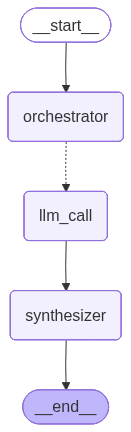

본 보고서는 최신 인공지능 및 소프트웨어 개발 환경에서 주목받고 있는 랭그래프 오케스트레이션(LangGraph Orchestration)과 워커 법칙(Worker Principle)에 대한 이해를 목표로 한다. 급변하는 디지털 환경에서 시스템의 효율적 관리와 확장성을 확보하는 일은 필수적이며, 이를 위한 다양한 아키텍처와 프로그래밍 대응법이 연이어 등장하고 있다.

랭그래프 오케스트레이션은 복잡한 언어 모델 기반 작업 흐름을 체계적으로 구성하고 관리할 수 있도록 돕는 프레임워크이다. 다양한 서비스와 에이전트, 워크플로우의 통합을 용이하게 하며, 모듈 간 상호작용의 유연성과 확장성, 그리고 장애에 대한 견고성을 제공한다. 대규모 언어 모델이 실제 서비스에 원활히 도입될 수 있도록 핵심적인 역할을 수행하고 있다.

한편, 워커 법칙은 분산 처리 및 병렬 작업 환경에서 개별 작업 단위(워커)의 역할과 책임, 그리고 서로 간의 동작 원칙을 정의한다. 이를 통해 시스템 전체의 안정성과 작업 효율성을 극대화하며, 장애 상황에 대한 회복력도 보장한다. 워커 법칙은 오케스트레이션 시스템 설계의 기본 지침으로서 신뢰받고 있다.

이 보고서에서는 두 개념의 주요 원리와 적용 방법, 실제 사례를 바탕으로 효과적 오케스트레이션 및 분산 시스템 구현을 위한 가이드라인을 제공한다.

---

랭그래프 오케스트레이션은 생성형 AI 및 자연어 처리(NLP)와 같은 언어 모델을 다양한 애플리케이션 내에서 효과적으로 통합, 관리, 실행할 수 있도록 돕는 시스템 혹은 프레임워크를 의미한다. 빠르게 변화하는 인공지능 환경에서 복잡한 업무 플로우를 효율적으로 구성하고, 다양한 언어 모델과 데이터 소스 간의 상호작용을 자동화하는 것이 핵심적인 목적이다.

주요 기능으로는 언어 모델 호출의 흐름 제어, 멀티모달 데이터 처리, 외부 API와의 통합, 사용자 요청에 따른 동적 작업 분기, 에이전트 기능 결합 등이 있다. 이를 통해 개발자는 복잡한 프롬프트 체인(prompt chain), 모델 간 협업, 

In [19]:
# 다이어그램 출력
display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))

# 실행
state = orchestrator_worker.invoke({"topic": "랭그래프 오케스트레이션-워커 법칙에 관한 보고서"})
print(state["final_report"])


In [20]:
# 평가자-개선자

# 그래프 상태
class State(TypedDict):
    joke: str          # 현재 농담
    topic: str         # 주제
    feedback: str      # 평가자 피드백(개선 시 참고)
    funny_or_not: str  # 평가 등급("funny" / "not funny")

# 평가에 사용할 구조화 출력 스키마
class Feedback(BaseModel):
    grade: Literal["funny", "not funny"] = Field(
        description="농담이 재미있는지(funny) 아닌지(not funny) 판단하세요."
    )
    feedback: str = Field(
        description="재미없다면 어떻게 개선할지 구체적인 피드백을 작성하세요."
    )

# 평가자 LLM: 구조화 출력으로 등급과 피드백을 반환
evaluator = llm.with_structured_output(Feedback)


In [21]:
# 1) 생성자: 농담 생성(피드백이 있으면 반영하여 개선)
def llm_call_generator(state: State):
    if state.get("feedback"):
        msg = llm.invoke(
            f"주제: {state['topic']}\n"
            f"아래 피드백을 반영하여 더 재미있는 농담을 작성해 주세요.\n"
            f"[피드백]: {state['feedback']}"
        )
    else:
        msg = llm.invoke(f"주제: {state['topic']}\n짧고 재치 있는 농담을 작성해 주세요.")
    return {"joke": msg.content}

# 2) 평가자: 농담 평가(등급 + 개선 피드백을 구조화하여 반환)
def llm_call_evaluator(state: State):
    grade = evaluator.invoke(
        f"다음 농담이 재미있는지 평가하고, 필요하면 개선 피드백을 주세요.\n[농담]: {state['joke']}"
    )
    return {"funny_or_not": grade.grade, "feedback": grade.feedback}

# 3) 분기: 평가 결과에 따라 종료/재생성 결정
def route_joke(state: State):
    if state["funny_or_not"] == "funny":
        return "Accepted"
    elif state["funny_or_not"] == "not funny":
        return "Rejected + Feedback"


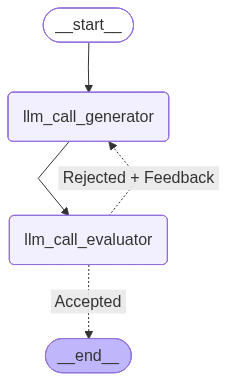

네, 피드백을 반영해서 더 직관적이고 상황에 맞는, 그리고 요즘 한국식 개그 코드를 살려서 농담을 작성해 볼게요!

---

"한국에서 치킨이 항상 도망가는 이유 아세요?  
치킨값이 너무 비싸서, 본인도 자기가 누구인지 모르겠다네요. 자기 정체성이 금(金)닭인 줄 안대요!"

---

또는,

"한국 치킨이 항상 도망가는 이유?  
배달앱에서 자꾸 인기 메뉴로 떠서, 숨고 싶대요!"

---

혹은,

"왜 한국 치킨은 언제나 숨어있을까요?  
치느님이라, 잡히면 인간계에 계시를 내릴 수 없으니까요!"

재미와 상황, 유행어를 섞어 다양하게 응용해 보았습니다!


In [22]:
# 그래프 구성
optimizer_builder = StateGraph(State)
optimizer_builder.add_node("llm_call_generator", llm_call_generator)
optimizer_builder.add_node("llm_call_evaluator", llm_call_evaluator)

optimizer_builder.add_edge(START, "llm_call_generator")
optimizer_builder.add_edge("llm_call_generator", "llm_call_evaluator")
optimizer_builder.add_conditional_edges(
    "llm_call_evaluator",
    route_joke,
    {
        "Accepted": END,
        "Rejected + Feedback": "llm_call_generator",
    },
)

# 컴파일
optimizer_workflow = optimizer_builder.compile()

# 다이어그램 확인
display(Image(optimizer_workflow.get_graph().draw_mermaid_png()))

# 실행
state = optimizer_workflow.invoke({"topic": "한국"})
print(state["joke"])


In [23]:
# 에이전트 

from langchain_core.tools import tool

@tool
def multiply(a: int, b: int) -> int:
    """두 수를 곱합니다."""
    return a * b

@tool
def add(a: int, b: int) -> int:
    """두 수를 더합니다."""
    return a + b

@tool
def divide(a: int, b: int) -> float:
    """두 수를 나눕니다."""
    return a / b


In [24]:
tools = [add, multiply, divide]
tools_by_name = {tool.name: tool for tool in tools}
llm_with_tools = llm.bind_tools(tools)

from langgraph.graph import MessagesState
from langchain_core.messages import SystemMessage, HumanMessage, ToolMessage

# LLM 호출 노드
def llm_call(state: MessagesState):
    """LLM이 도구 호출 여부를 결정"""
    return {
        "messages": [
            llm_with_tools.invoke(
                [SystemMessage(content="당신은 주어진 입력값으로 산술 연산을 수행하는 유용한 어시스턴트입니다.")]
                + state["messages"]
            )
        ]
    }


In [25]:
# 도구 실행 노드
def tool_node(state: dict):
    """LLM이 요청한 도구를 실행"""
    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    return {"messages": result}


In [26]:
# 반복 여부 판단
def should_continue(state: MessagesState) -> Literal["environment", END]:
    """도구 호출이 있으면 계속, 없으면 종료"""
    if state["messages"][-1].tool_calls:
        return "Action"
    return END


In [27]:
# 에이전트 워크플로 구성
agent_builder = StateGraph(MessagesState)
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("environment", tool_node)

agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    {"Action": "environment", END: END},
)
agent_builder.add_edge("environment", "llm_call")

agent = agent_builder.compile()

# 실행
messages = [HumanMessage(content="3과 4를 더하세요.")]
messages = agent.invoke({"messages": messages})
for m in messages["messages"]:
    m.pretty_print()


================================ Human Message =================================

3과 4를 더하세요.
================================== Ai Message ==================================
Tool Calls:
  add (call_N63cpB2wzN8ROboFXFWwWRkx)
 Call ID: call_N63cpB2wzN8ROboFXFWwWRkx
  Args:
    a: 3
    b: 4
================================= Tool Message =================================

7
================================== Ai Message ==================================

3과 4를 더하면 7입니다.
